In [41]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt

In [20]:
data = pd.read_csv("./data-studenten.csv")
data

,Unnamed: 0,Individu-ID,geslacht,leeftijd,opleidingsniveau,sigaretten_per_dag,slaapscore,hypertensie,hartinfarct,diabetes,nierziekte,cholesterol,bovendruk,onderdruk,BMI,hartslag,glucose,prognose10jaar
0,47,#235527,M,46,2,0,58,-,-,-,-,217,117.5,77.5,32,55,83,CHD-
1,459,#147320,M,48,1,15,35,-,-,-,-,240,126.0,84.0,25,73,60,CHD-
2,395,#231103,V,61,1,3,31,+,-,-,-,201,145.0,88.0,39,65,89,CHD-
3,144,#101995,V,65,1,20,42,-,-,-,-,238,136.0,66.0,20,60,92,CHD+
4,650,#124541,M,43,4,20,94,-,-,-,-,270,112.0,77.0,24,73,85,CHD-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,386,#262939,V,50,3,0,33,-,-,-,-,257,128.0,77.0,24,68,88,CHD-
896,437,#200040,M,65,1,0,48,+,-,-,-,234,130.0,83.0,27,75,74,CHD-
897,533,#227349,M,47,1,9,52,-,-,-,-,255,113.5,72.5,23,60,?,CHD-
898,992,#148412,V,33,2,5,45,-,-,-,-,200,119.0,74.0,23,75,74,CHD-


In [21]:
data.replace({"+":True, "-":False, "?":None}, inplace=True)
data

/tmp/ipykernel_9346/154776037.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"+":True, "-":False, "?":None}, inplace=True)


,Unnamed: 0,Individu-ID,geslacht,leeftijd,opleidingsniveau,sigaretten_per_dag,slaapscore,hypertensie,hartinfarct,diabetes,nierziekte,cholesterol,bovendruk,onderdruk,BMI,hartslag,glucose,prognose10jaar
0,47,#235527,M,46,2,0,58,False,False,False,False,217,117.5,77.5,32,55,83,CHD-
1,459,#147320,M,48,1,15,35,False,False,False,False,240,126.0,84.0,25,73,60,CHD-
2,395,#231103,V,61,1,3,31,True,False,False,False,201,145.0,88.0,39,65,89,CHD-
3,144,#101995,V,65,1,20,42,False,False,False,False,238,136.0,66.0,20,60,92,CHD+
4,650,#124541,M,43,4,20,94,False,False,False,False,270,112.0,77.0,24,73,85,CHD-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,386,#262939,V,50,3,0,33,False,False,False,False,257,128.0,77.0,24,68,88,CHD-
896,437,#200040,M,65,1,0,48,True,False,False,False,234,130.0,83.0,27,75,74,CHD-
897,533,#227349,M,47,1,9,52,False,False,False,False,255,113.5,72.5,23,60,None,CHD-
898,992,#148412,V,33,2,5,45,False,False,False,False,200,119.0,74.0,23,75,74,CHD-


In [22]:
pd.DataFrame({
    "isna": data.isna().sum()
})

,isna
Unnamed: 0,0
Individu-ID,0
geslacht,0
leeftijd,0
opleidingsniveau,27
sigaretten_per_dag,6
slaapscore,0
hypertensie,0
hartinfarct,0
diabetes,0


In [23]:
data.dropna(inplace=True)
data

,Unnamed: 0,Individu-ID,geslacht,leeftijd,opleidingsniveau,sigaretten_per_dag,slaapscore,hypertensie,hartinfarct,diabetes,nierziekte,cholesterol,bovendruk,onderdruk,BMI,hartslag,glucose,prognose10jaar
0,47,#235527,M,46,2,0,58,False,False,False,False,217,117.5,77.5,32,55,83,CHD-
1,459,#147320,M,48,1,15,35,False,False,False,False,240,126.0,84.0,25,73,60,CHD-
2,395,#231103,V,61,1,3,31,True,False,False,False,201,145.0,88.0,39,65,89,CHD-
3,144,#101995,V,65,1,20,42,False,False,False,False,238,136.0,66.0,20,60,92,CHD+
4,650,#124541,M,43,4,20,94,False,False,False,False,270,112.0,77.0,24,73,85,CHD-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,964,#330993,V,55,3,0,51,True,False,False,False,237,153.0,80.0,28,74,72,CHD-
894,149,#208879,V,39,3,0,74,False,False,False,True,180,136.5,89.0,17,84,77,CHD-
895,386,#262939,V,50,3,0,33,False,False,False,False,257,128.0,77.0,24,68,88,CHD-
896,437,#200040,M,65,1,0,48,True,False,False,False,234,130.0,83.0,27,75,74,CHD-


In [30]:
data.dtypes

Unnamed: 0              int64
Individu-ID            object
geslacht               object
leeftijd                int64
opleidingsniveau       object
sigaretten_per_dag     object
slaapscore              int64
hypertensie              bool
hartinfarct              bool
diabetes                 bool
nierziekte             object
cholesterol            object
bovendruk             float64
onderdruk             float64
BMI                    object
hartslag                int64
glucose                object
prognose10jaar         object
dtype: object

In [36]:
data = data.astype({"opleidingsniveau": "int64", "sigaretten_per_dag": "int64", "nierziekte": "bool", "cholesterol": "int64", "glucose": "int64", "BMI": "int64"})
data.dtypes

Unnamed: 0              int64
Individu-ID            object
geslacht               object
leeftijd                int64
opleidingsniveau        int64
sigaretten_per_dag      int64
slaapscore              int64
hypertensie              bool
hartinfarct              bool
diabetes                 bool
nierziekte               bool
cholesterol             int64
bovendruk             float64
onderdruk             float64
BMI                     int64
hartslag                int64
glucose                 int64
prognose10jaar         object
dtype: object

In [37]:
encoder = sklearn.preprocessing.OneHotEncoder(sparse_output=False)

categorical_columns = data.select_dtypes(include=['object']).columns.tolist()

categorical_columns.remove("Individu-ID")

one_hot_encoded_columns = encoder.fit_transform(data[categorical_columns])

one_hot_data = pd.DataFrame(one_hot_encoded_columns, columns=encoder.get_feature_names_out(categorical_columns))

encoded_data = pd.concat([data, one_hot_data], axis=1)

encoded_data.drop(categorical_columns, axis=1, inplace=True)
encoded_data.dropna(inplace=True)
encoded_data

,Unnamed: 0,Individu-ID,leeftijd,opleidingsniveau,sigaretten_per_dag,slaapscore,hypertensie,hartinfarct,diabetes,nierziekte,cholesterol,bovendruk,onderdruk,BMI,hartslag,glucose,geslacht_M,geslacht_V,prognose10jaar_CHD+,prognose10jaar_CHD-
0,47.0,#235527,46.0,2.0,0.0,58.0,False,False,False,False,217.0,117.5,77.5,32.0,55.0,83.0,1.0,0.0,0.0,1.0
1,459.0,#147320,48.0,1.0,15.0,35.0,False,False,False,False,240.0,126.0,84.0,25.0,73.0,60.0,1.0,0.0,0.0,1.0
2,395.0,#231103,61.0,1.0,3.0,31.0,True,False,False,False,201.0,145.0,88.0,39.0,65.0,89.0,0.0,1.0,0.0,1.0
3,144.0,#101995,65.0,1.0,20.0,42.0,False,False,False,False,238.0,136.0,66.0,20.0,60.0,92.0,0.0,1.0,1.0,0.0
4,650.0,#124541,43.0,4.0,20.0,94.0,False,False,False,False,270.0,112.0,77.0,24.0,73.0,85.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,276.0,#128059,45.0,2.0,0.0,25.0,False,False,False,False,210.0,133.0,85.5,25.0,75.0,90.0,0.0,1.0,0.0,1.0
776,137.0,#205783,52.0,2.0,0.0,24.0,True,False,False,True,309.0,177.5,110.0,22.0,63.0,73.0,1.0,0.0,0.0,1.0
777,941.0,#158876,54.0,1.0,0.0,25.0,False,False,False,False,254.0,136.5,83.0,20.0,88.0,95.0,1.0,0.0,1.0,0.0
780,902.0,#120695,49.0,1.0,35.0,27.0,False,False,False,True,263.0,132.0,91.0,40.0,90.0,91.0,0.0,1.0,0.0,1.0


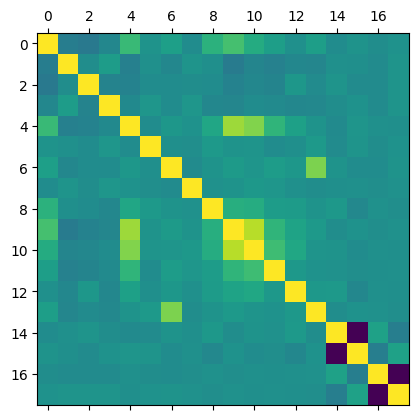

In [42]:
corr_data = encoded_data.drop(columns=["Unnamed: 0", "Individu-ID"]).corr()

plt.matshow(corr_data)
plt.show()

In [ ]:
sklearn.model_selection.train_test_split(data)